# Lead Conversion Prediction

## Business Context
EdTech platforms like ExtraaLearn generate large volumes of leads, but only a fraction 
convert to paying customers. Identifying high-probability leads early allows sales teams 
to allocate resources efficiently and improve conversion rates.

## Objective
Using behavioral and demographic data from ExtraaLearn, this project:
* Builds a classification model to predict lead conversion probability
* Identifies the key factors driving conversion
* Provides actionable recommendations for sales prioritization

## Data Description
4,612 leads with 14 features capturing demographics, platform behavior, and marketing 
touchpoints. Target variable: `status` (1 = converted, 0 = not converted).

| Feature | Description |
|---|---|
| `age` | Age of the lead |
| `current_occupation` | Professional, Student, or Unemployed |
| `first_interaction` | Website or Mobile App |
| `profile_completed` | Low / Medium / High completion |
| `website_visits` | Number of website visits |
| `time_spent_on_website` | Total seconds spent on site |
| `page_views_per_visit` | Average pages viewed per visit |
| `last_activity` | Email, Phone, or Website activity |
| `print_media_type1/2` | Newspaper / Magazine ad exposure |
| `digital_media` | Digital platform ad exposure |
| `educational_channels` | Heard via education forums |
| `referral` | Heard via referral |

## Libraries

In [1]:
# Standard library
import os
import sys
import warnings

sys.path.append(os.path.abspath(".."))
warnings.filterwarnings("ignore")

# Data
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Modeling
from sklearn.compose import make_column_transformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier

# Serialization
import joblib

# Lab engine
from core.evaluation import model_performance_classification, train_and_evaluate
from core.visualization import (
    categorical_overview,
    distribution_plot_wrt_target,
    head_and_tail,
    histogram_boxplot,
    labeled_barplot,
    set_style,
    stacked_barplot,
)

# Local
from src.data_preprocessing import preprocess_data

In [2]:
set_style()

# **Loading the dataset**

In [3]:
original_dataset = pd.read_csv('../data/ExtraaLearn.csv')

In [4]:
data = original_dataset.copy()

## Overview of the dataset

In [5]:
head_and_tail(data)

Head:


,ID,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
0,EXT001,57,Unemployed,Website,High,7,1639,1.861,Website Activity,Yes,No,Yes,No,No,1
1,EXT002,56,Professional,Mobile App,Medium,2,83,0.320,Website Activity,No,No,No,Yes,No,0
2,EXT003,52,Professional,Website,Medium,3,330,0.074,Website Activity,No,No,Yes,No,No,0
3,EXT004,53,Unemployed,Website,High,4,464,2.057,Website Activity,No,No,No,No,No,1
4,EXT005,23,Student,Website,High,4,600,16.914,Email Activity,No,No,No,No,No,0



Tail:


,ID,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
4607,EXT4608,35,Unemployed,Mobile App,Medium,15,360,2.170,Phone Activity,No,No,No,Yes,No,0
4608,EXT4609,55,Professional,Mobile App,Medium,8,2327,5.393,Email Activity,No,No,No,No,No,0
4609,EXT4610,58,Professional,Website,High,2,212,2.692,Email Activity,No,No,No,No,No,1
4610,EXT4611,57,Professional,Mobile App,Medium,1,154,3.879,Website Activity,Yes,No,No,No,No,0
4611,EXT4612,55,Professional,Website,Medium,4,2290,2.075,Phone Activity,No,No,No,No,No,0


In [6]:
data.shape

(4612, 15)

* The dataset has 4612 rows and 15 columns

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4612 entries, 0 to 4611
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     4612 non-null   object 
 1   age                    4612 non-null   int64  
 2   current_occupation     4612 non-null   object 
 3   first_interaction      4612 non-null   object 
 4   profile_completed      4612 non-null   object 
 5   website_visits         4612 non-null   int64  
 6   time_spent_on_website  4612 non-null   int64  
 7   page_views_per_visit   4612 non-null   float64
 8   last_activity          4612 non-null   object 
 9   print_media_type1      4612 non-null   object 
 10  print_media_type2      4612 non-null   object 
 11  digital_media          4612 non-null   object 
 12  educational_channels   4612 non-null   object 
 13  referral               4612 non-null   object 
 14  status                 4612 non-null   int64  
dtypes: f

* No null values across all 4,612 records. 10 categorical features, 4 numerical, 1 float. Target variable: `status` (int).

In [8]:
data.duplicated().sum()

np.int64(0)

In [9]:
data["ID"].nunique()

4612

* Dataset has no duplicate values. All ID values are unique.

In [10]:
data.columns.tolist()

['ID',
 'age',
 'current_occupation',
 'first_interaction',
 'profile_completed',
 'website_visits',
 'time_spent_on_website',
 'page_views_per_visit',
 'last_activity',
 'print_media_type1',
 'print_media_type2',
 'digital_media',
 'educational_channels',
 'referral',
 'status']

## Preprocessing

The ID column is dropped as it carries no predictive value.

In [11]:
data = preprocess_data(data)
data

,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
0,57,Unemployed,Website,High,7,1639,1.861,Website Activity,Yes,No,Yes,No,No,1
1,56,Professional,Mobile App,Medium,2,83,0.320,Website Activity,No,No,No,Yes,No,0
2,52,Professional,Website,Medium,3,330,0.074,Website Activity,No,No,Yes,No,No,0
3,53,Unemployed,Website,High,4,464,2.057,Website Activity,No,No,No,No,No,1
4,23,Student,Website,High,4,600,16.914,Email Activity,No,No,No,No,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4607,35,Unemployed,Mobile App,Medium,15,360,2.170,Phone Activity,No,No,No,Yes,No,0
4608,55,Professional,Mobile App,Medium,8,2327,5.393,Email Activity,No,No,No,No,No,0
4609,58,Professional,Website,High,2,212,2.692,Email Activity,No,No,No,No,No,1
4610,57,Professional,Mobile App,Medium,1,154,3.879,Website Activity,Yes,No,No,No,No,0


In [12]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,4612.0,46.201214,13.161454,18.0,36.00000,51.000,57.00000,63.000
website_visits,4612.0,3.566782,2.829134,0.0,2.00000,3.000,5.00000,30.000
time_spent_on_website,4612.0,724.011275,743.828683,0.0,148.75000,376.000,1336.75000,2537.000
page_views_per_visit,4612.0,3.026126,1.968125,0.0,2.07775,2.792,3.75625,18.434
status,4612.0,0.298569,0.457680,0.0,0.00000,0.000,1.00000,1.000


In [13]:
data.isnull().sum()

age                      0
current_occupation       0
first_interaction        0
profile_completed        0
website_visits           0
time_spent_on_website    0
page_views_per_visit     0
last_activity            0
print_media_type1        0
print_media_type2        0
digital_media            0
educational_channels     0
referral                 0
status                   0
dtype: int64

* There are no null values in the dataset.

# **Exploratory Data Analysis**

In [14]:
cat_cols = list(data.select_dtypes("object").columns)

for column in cat_cols:
    print(data[column].value_counts())
    print("-" * 50)

current_occupation
Professional    2616
Unemployed      1441
Student          555
Name: count, dtype: int64
--------------------------------------------------
first_interaction
Website       2542
Mobile App    2070
Name: count, dtype: int64
--------------------------------------------------
profile_completed
High      2264
Medium    2241
Low        107
Name: count, dtype: int64
--------------------------------------------------
last_activity
Email Activity      2278
Phone Activity      1234
Website Activity    1100
Name: count, dtype: int64
--------------------------------------------------
print_media_type1
No     4115
Yes     497
Name: count, dtype: int64
--------------------------------------------------
print_media_type2
No     4379
Yes     233
Name: count, dtype: int64
--------------------------------------------------
digital_media
No     4085
Yes     527
Name: count, dtype: int64
--------------------------------------------------
educational_channels
No     3907
Yes     705
Name

### Overview of categorical variables
Here we'll have a glance at the percentage count for each categorical variable.          n = 4612

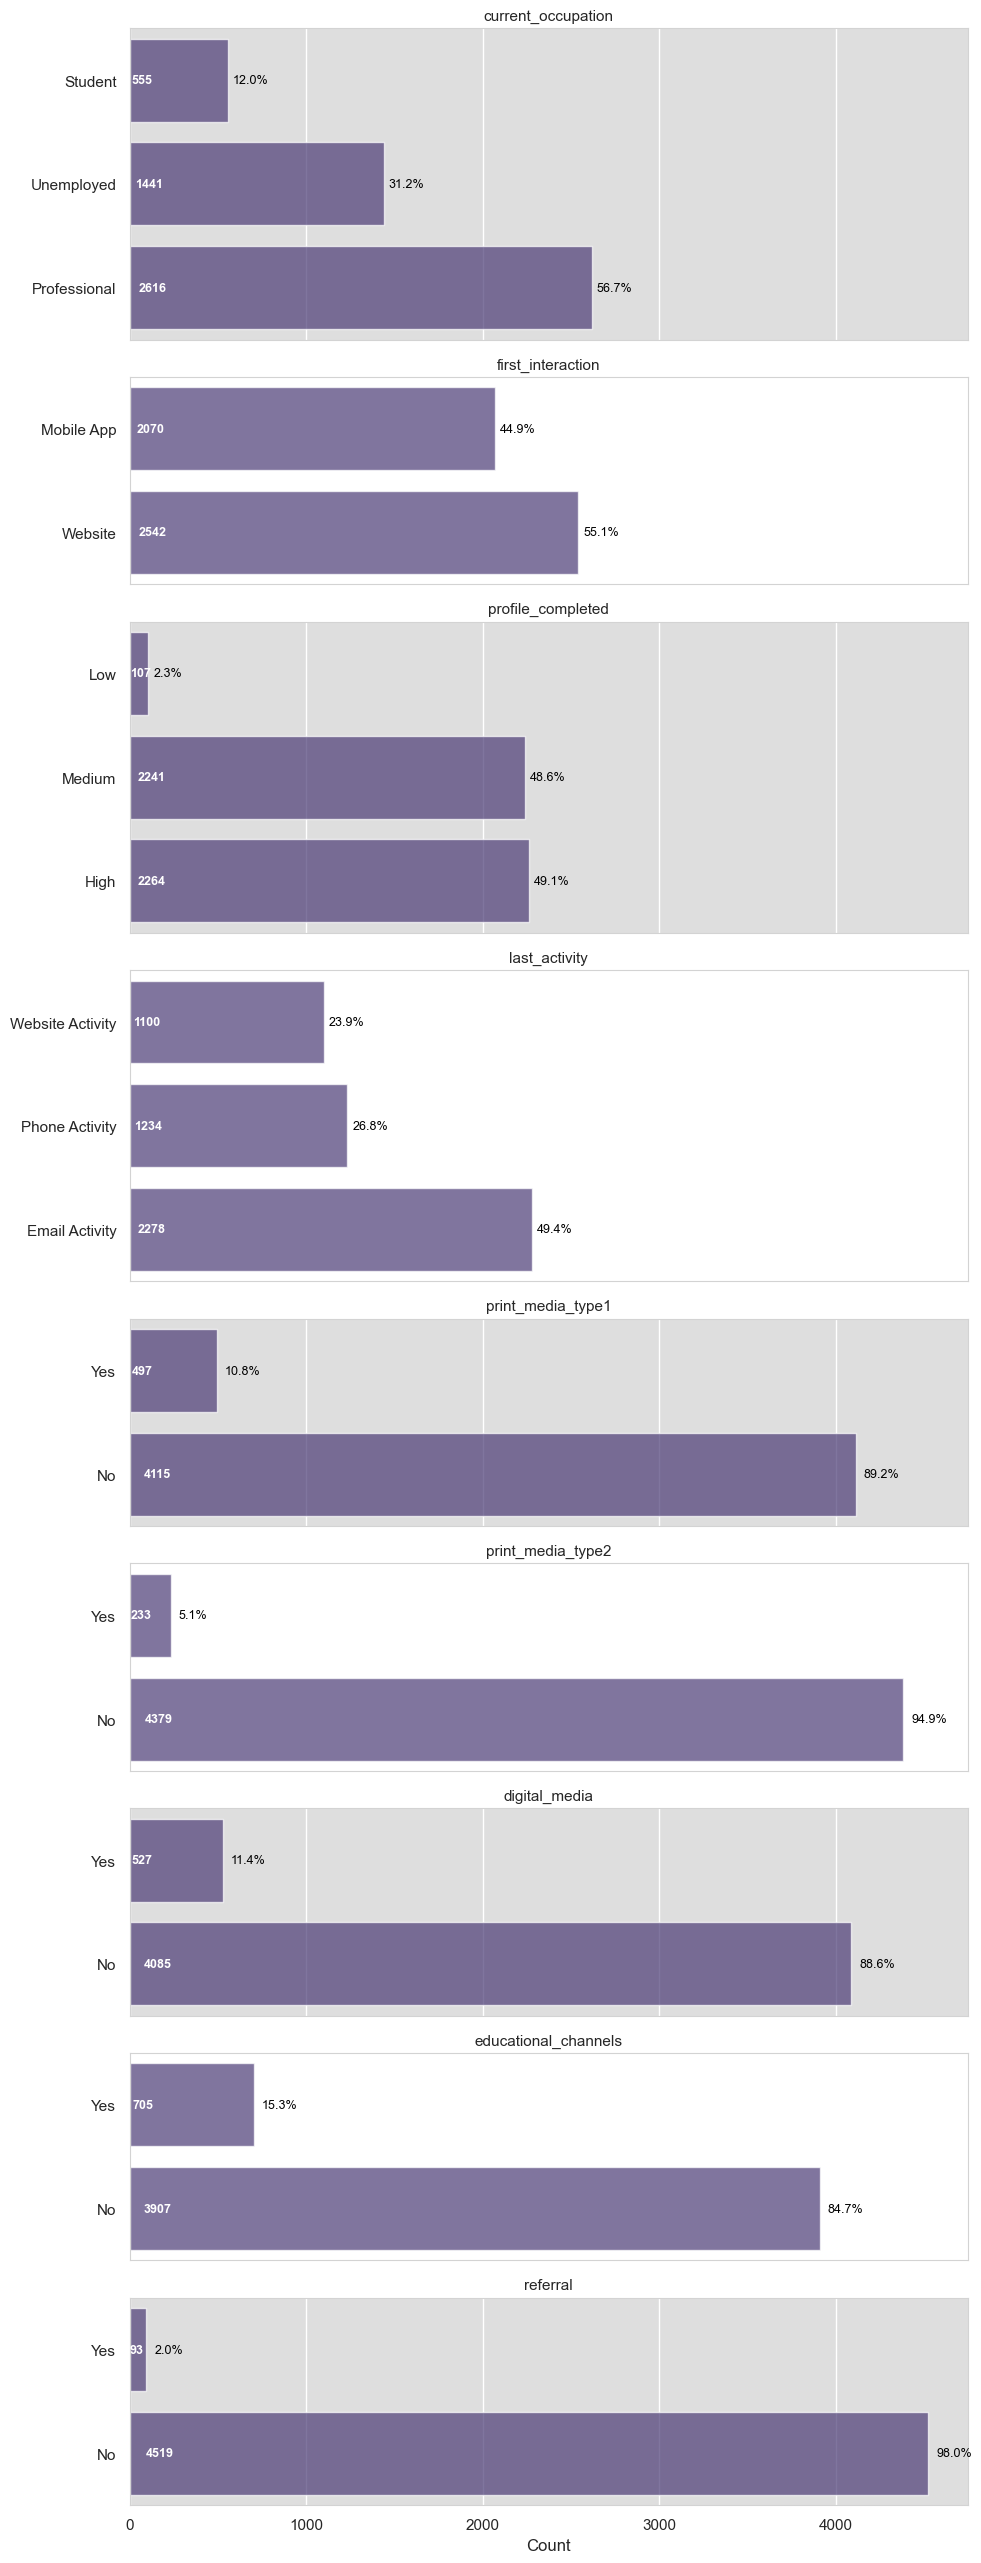

In [15]:
categorical_overview(data, cat_cols)

* Shared count axis allows direct comparison of class distribution across all categorical features, revealing imbalance at a glance.

### Overview of numerical variables

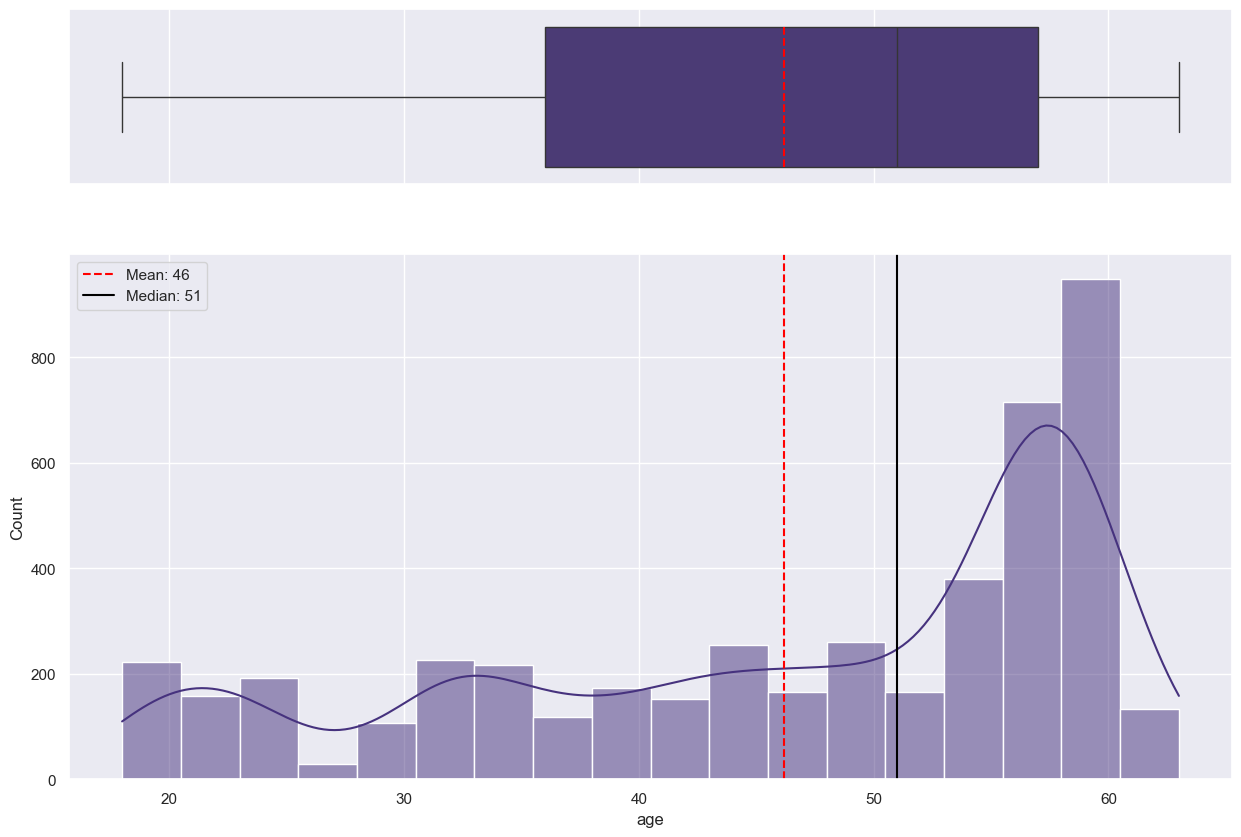

In [16]:
histogram_boxplot(data, "age", kde=True)

* Age is left skewed, with the mean around 46 and the median around 51.

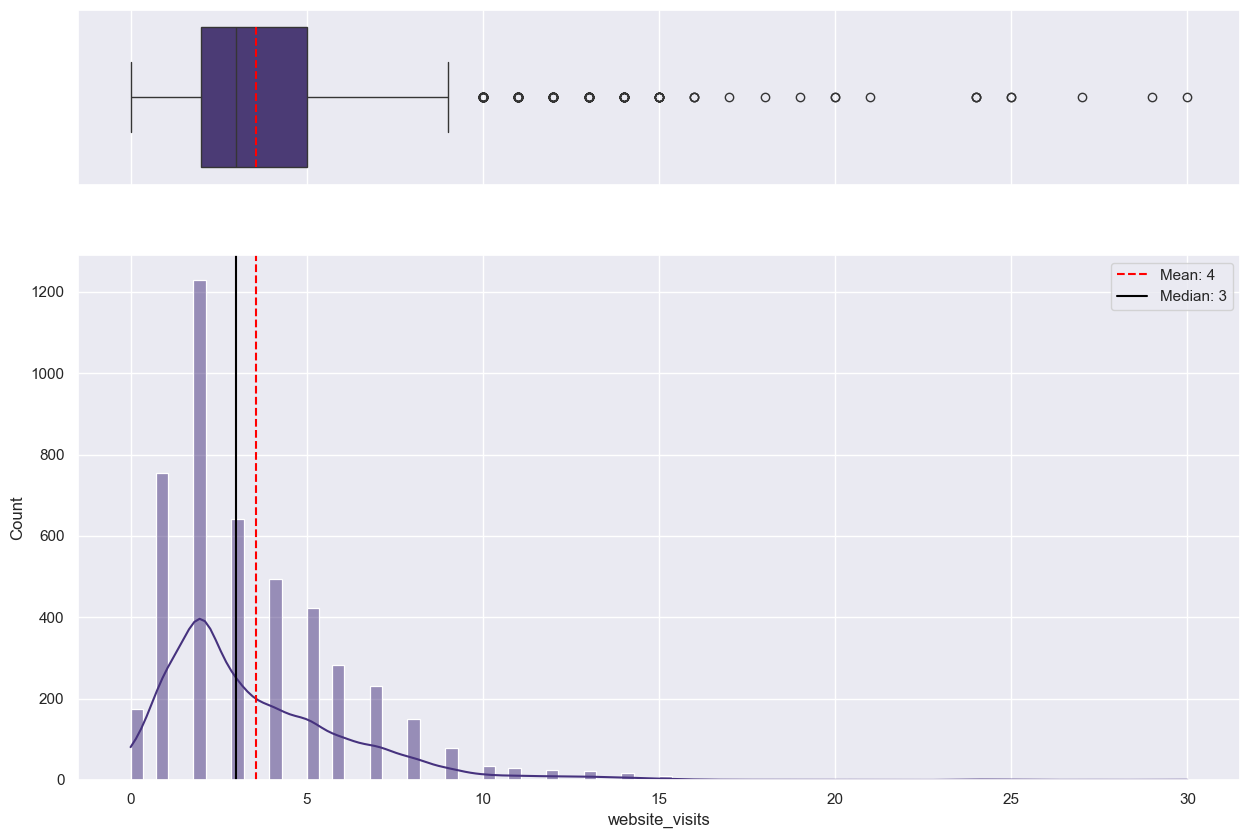

In [17]:
histogram_boxplot(data, "website_visits", kde=True)

* 75% of the leads have visited the website less than 5 times.

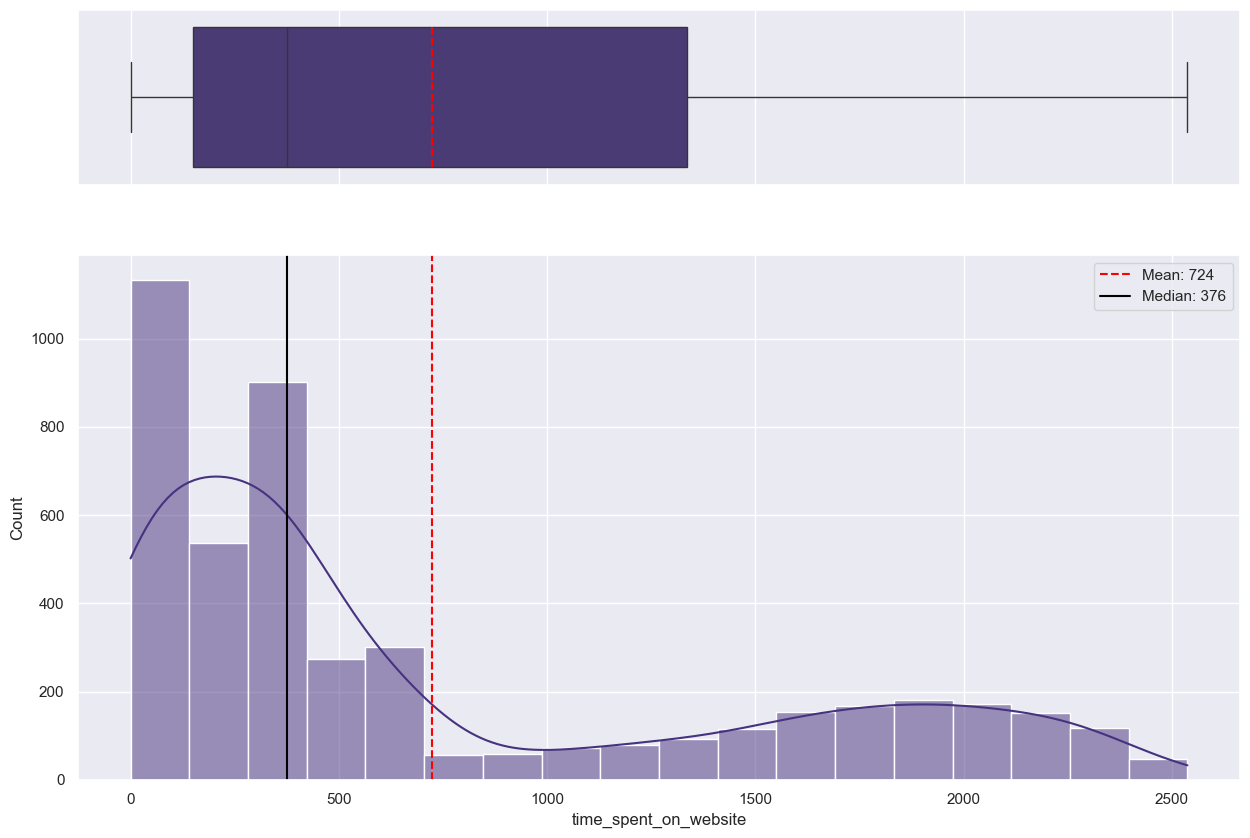

In [18]:
histogram_boxplot(data, "time_spent_on_website", kde=True)

* Time spent on website is right skewed — most leads spent fewer than 1,500 seconds on the site.

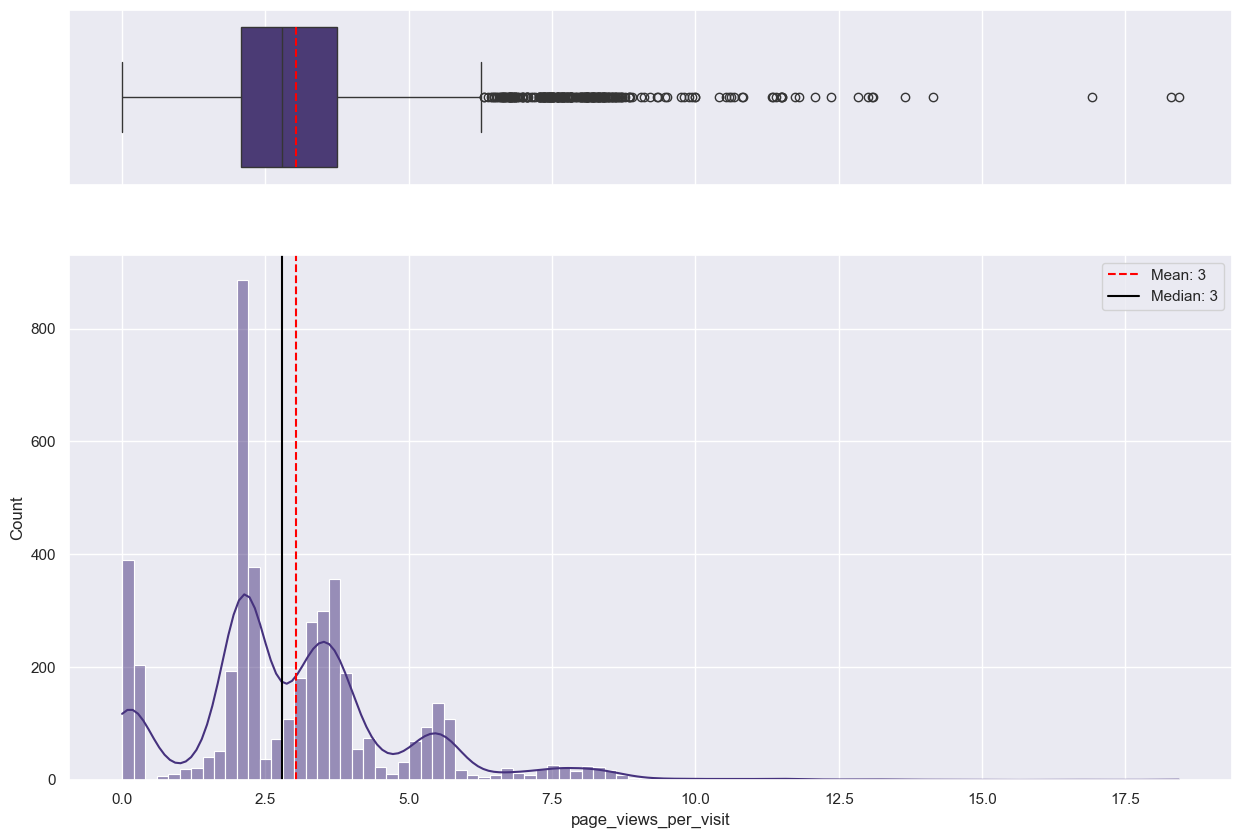

In [19]:
histogram_boxplot(data, "page_views_per_visit", kde=True)

* Page views per visit is right skewed. The high concentration of leads with near-zero or zero page views pulls the mean and median closer together than typical right skewed distributions.

### Bivariate Analysis

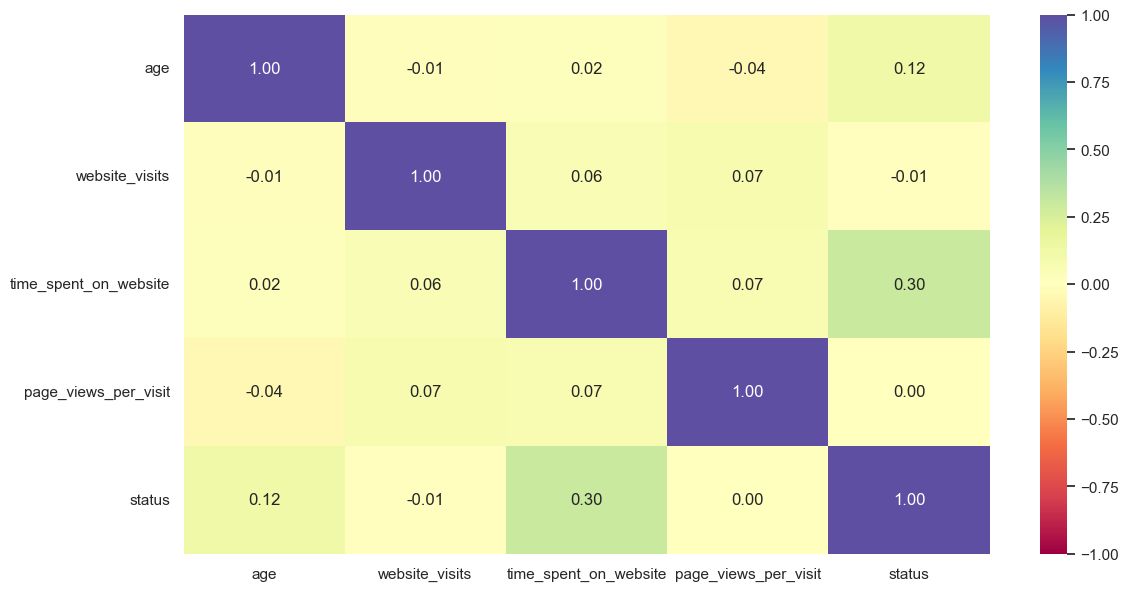

In [20]:
plt.figure(figsize=(13, 7))
sns.heatmap(data.select_dtypes(include=np.number).corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

* Time spent on website is the strongest predictor of conversion (status) among numerical features. Age shows slight positive correlation. Remaining numerical variables show negligible correlation with the target.

status                 0     1   All
current_occupation                  
All                 3235  1377  4612
Professional        1687   929  2616
Unemployed          1058   383  1441
Student              490    65   555
------------------------------------------------------------------------------------------------------------------------


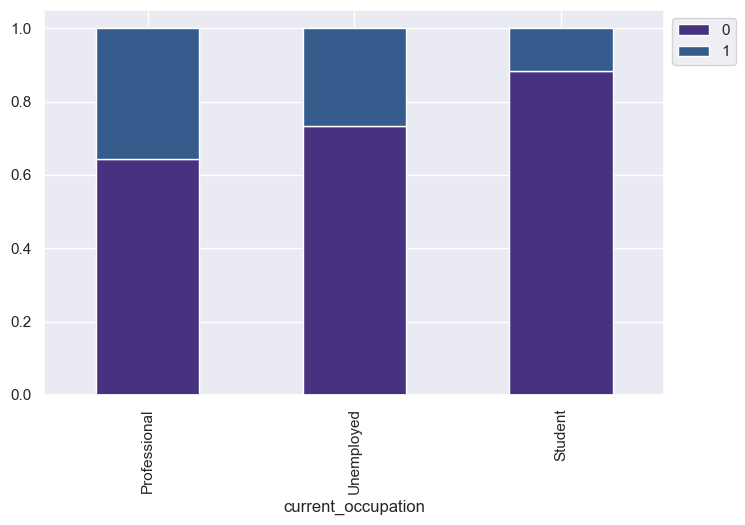

In [21]:
stacked_barplot(data, "current_occupation", "status")

* Professionals represent the largest and highest-converting segment among all occupations.

status                0     1   All
first_interaction                  
All                3235  1377  4612
Website            1383  1159  2542
Mobile App         1852   218  2070
------------------------------------------------------------------------------------------------------------------------


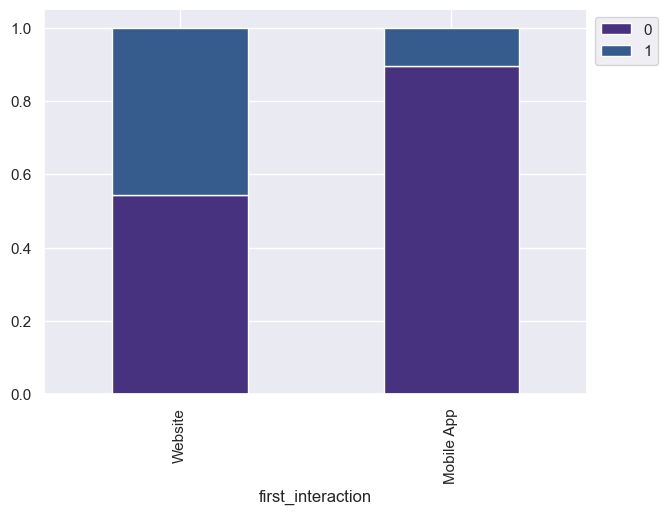

In [22]:
stacked_barplot(data, "first_interaction", "status")

* Website is the dominant first interaction channel, and leads who first interact via website convert at a higher rate.

status                0     1   All
profile_completed                  
All                3235  1377  4612
High               1318   946  2264
Medium             1818   423  2241
Low                  99     8   107
------------------------------------------------------------------------------------------------------------------------


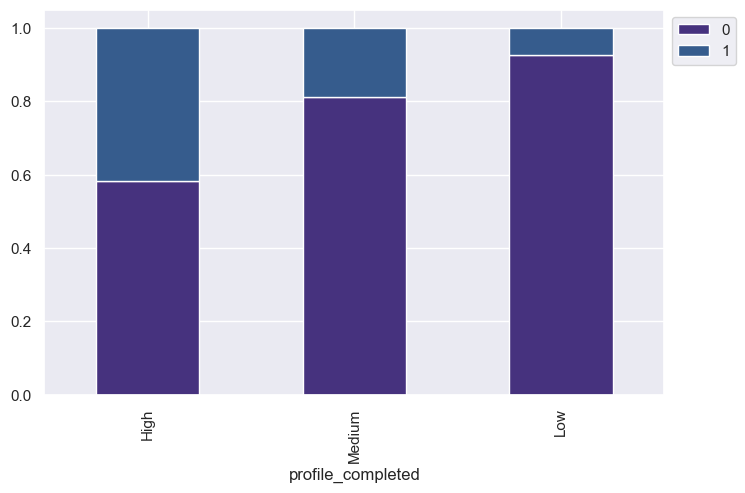

In [23]:
stacked_barplot(data, "profile_completed", "status")

* Profile completion is strongly associated with conversion — high completion leads convert most frequently and in the greatest numbers.

status               0     1   All
last_activity                     
All               3235  1377  4612
Email Activity    1587   691  2278
Website Activity   677   423  1100
Phone Activity     971   263  1234
------------------------------------------------------------------------------------------------------------------------


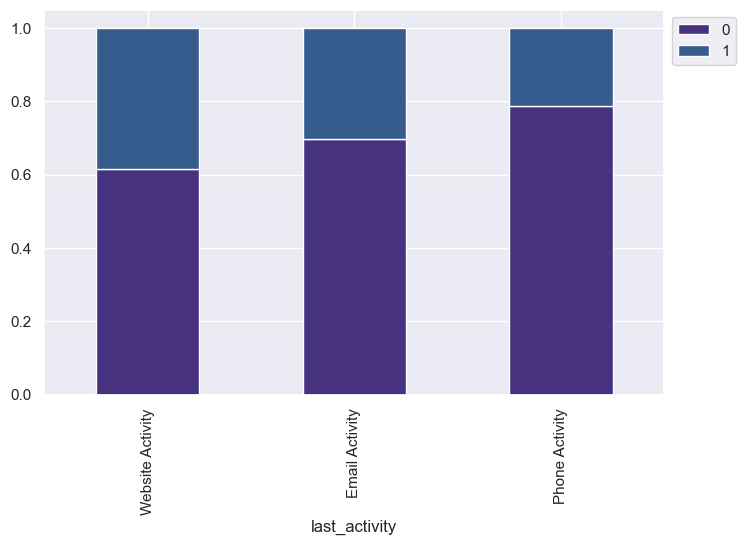

In [24]:
stacked_barplot(data, "last_activity", "status")

* Leads whose last activity was website interaction show the highest conversion proportion.

# **Data Preprocessing**

## Outlier Check

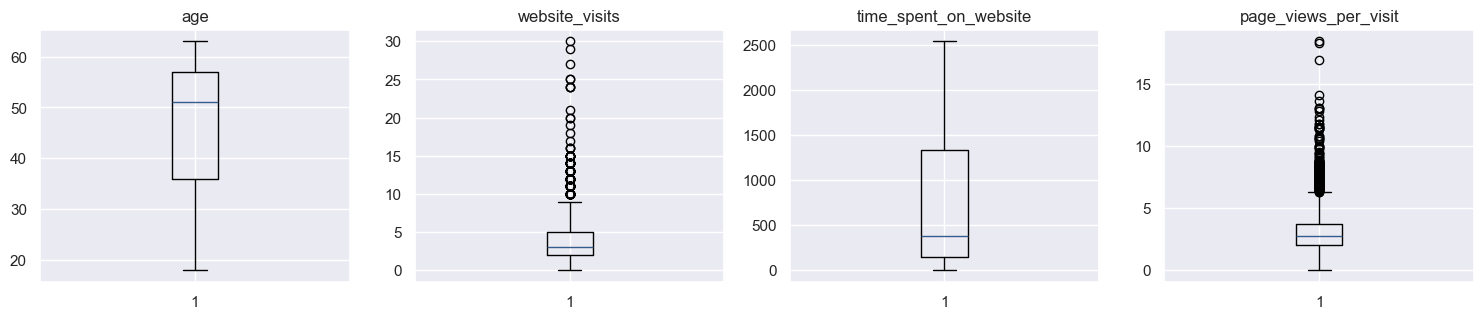

In [25]:
# outlier detection using boxplot
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()
numeric_columns.remove("status")

plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

* Outliers are present in website_visits and page_views_per_visit. Decision trees are robust to outliers by nature, so no treatment is applied.

## Data Preparation for modeling

The target variable is `status`. Categorical features require encoding before modeling. 
Data is split 70/30 into train and test sets. Class distribution is consistent across 
both splits (≈70/30), confirming the random split is representative.

In [26]:
X = data.drop(["status"], axis=1)
Y = data["status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.30, random_state=1
)

In [27]:
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (3228, 13)
Shape of test set :  (1384, 13)
Percentage of classes in training set:
status
0    0.704151
1    0.295849
Name: proportion, dtype: float64
Percentage of classes in test set:
status
0    0.695087
1    0.304913
Name: proportion, dtype: float64


The dataset presents a class imbalance (≈70% non-converted, 30% converted). 
Recall is prioritized as the key evaluation metric to minimize missed conversion opportunities.

## **Data Pre-processing Pipeline**

In [28]:
categorical_features = data.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_features

['current_occupation',
 'first_interaction',
 'profile_completed',
 'last_activity',
 'print_media_type1',
 'print_media_type2',
 'digital_media',
 'educational_channels',
 'referral']

In [29]:
preprocessor = make_column_transformer(
    (Pipeline([('encoder', OneHotEncoder(handle_unknown='ignore'))]), categorical_features),
    remainder="passthrough"
)

## Evaluation Criterion
Recall is prioritized as the primary metric because the business cost 
of missing a converter outweighs the cost of a false positive. F1, 
precision, and accuracy are tracked alongside for a complete picture.

# **Model Building**

We compare three models that span the two fundamental ensemble approaches:
an interpretable Decision Tree as a baseline, a Random Forest representing 
bagging (parallel trees on bootstrapped data, predictions averaged), and a 
Gradient Boosting Classifier representing boosting (trees built sequentially, 
each correcting the previous one's errors).

All three share the same preprocessing pipeline. We train each at its 
default hyperparameters first; the strongest performer is then tuned with 
GridSearchCV to extract its full capability.

### Models

In [30]:
models = [
    ("Decision Tree", DecisionTreeClassifier(random_state=1)),
    ("Random Forest", RandomForestClassifier(random_state=1)),
    ("Gradient Boosting", GradientBoostingClassifier(random_state=1)),
]

In [31]:
results = [
    train_and_evaluate(name, make_pipeline(preprocessor, estimator),
                       X_train, y_train, X_test, y_test)
    for name, estimator in models
]

In [32]:
test_comparison = pd.concat(
    [r["test_perf"].T for r in results],
    axis=1,
)
test_comparison.columns = [r["name"] for r in results]

print("Test performance comparison:")
test_comparison

Test performance comparison:


,Decision Tree,Random Forest,Gradient Boosting
Accuracy,0.792630,0.848988,0.856214
Recall,0.658768,0.684834,0.720379
Precision,0.660333,0.791781,0.789610
F1,0.659549,0.734435,0.753408


In [33]:
train_comparison = pd.concat(
    [r["train_perf"].T for r in results],
    axis=1,
)
train_comparison.columns = [r["name"] for r in results]

print("Training performance comparison:")
train_comparison

Training performance comparison:


,Decision Tree,Random Forest,Gradient Boosting
Accuracy,1.0,0.999690,0.886927
Recall,1.0,0.998953,0.770681
Precision,1.0,1.000000,0.834467
F1,1.0,0.999476,0.801306


Gradient Boosting performs best across every test metric — recall 72.0%, 
F1 75.3%, precision 79.0%, accuracy 85.6%. Random Forest is a close second 
(recall 68.5%, F1 73.4%), and both ensembles substantially outperform the 
single Decision Tree.

The training-set comparison reveals an important pattern: the Decision Tree 
and Random Forest both essentially memorize the training data (~100% on all 
metrics), while Gradient Boosting does not (~80% training metrics). The 
train/test gap is therefore much narrower for Gradient Boosting (~5 points) 
than for the other two (~30+ points). This reflects boosting's inherent 
regularization — each tree is a small, learning-rate-controlled correction 
rather than a free-fit, which keeps the ensemble from collapsing onto the 
training data.

Gradient Boosting is selected for hyperparameter tuning. Its combination of 
the highest test scores AND the smallest train/test gap makes it the most 
trustworthy generalizer of the three.

## Hyperparameter Tuning

Gradient Boosting is tuned using GridSearchCV with recall as the scoring 
metric and 5-fold cross-validation. The grid covers the three parameters 
that most directly control overfitting and generalization for boosting: 
`n_estimators` (how many trees to build), `max_depth` (complexity of each 
individual tree), and `learning_rate` (how much each tree corrects the 
prior ensemble — smaller = more cautious, requires more trees).

Note that boosting's default hyperparameters already encode meaningful 
regularization, so tuning gains are typically more modest than for an 
unconstrained model.

In [34]:
winner_name = "Gradient Boosting"
winner = next(r["model"] for r in results if r["name"] == winner_name)

parameters = {
    "gradientboostingclassifier__n_estimators": [100, 200],
    "gradientboostingclassifier__max_depth": [3, 5, 7],
    "gradientboostingclassifier__learning_rate": [0.05, 0.1, 0.2],
}

grid = GridSearchCV(winner, parameters, scoring="recall", cv=5, n_jobs=-1)
grid.fit(X_train, y_train)
print("Best parameters:", grid.best_params_)

model_tuned = grid.best_estimator_

KeyboardInterrupt: 

Tuning produces a more conservative model (smaller learning rate) with 
marginally lower test metrics (~0.5 points) but a tighter train/test gap 
(~3.1 vs 5.1 points). The default Gradient Boosting is selected as the 
final model: it wins on test recall — the priority metric — and the gap 
difference is small enough to attribute to noise. This confirms 
boosting's defaults are already well-regularized for this dataset; 
tuning explored the parameter space but did not improve generalization.

In [ ]:
tuned_result = train_and_evaluate(
    f"{winner_name} (tuned)",
    model_tuned,
    X_train, y_train, X_test, y_test,
)
results.append(tuned_result)

test_comparison = pd.concat([r["test_perf"].T for r in results], axis=1)
test_comparison.columns = [r["name"] for r in results]
print("Test performance with tuned winner:")
test_comparison

Test performance with tuned winner:


,Decision Tree,Random Forest,Gradient Boosting,Gradient Boosting (tuned)
Accuracy,0.792630,0.848988,0.856214,0.851879
Recall,0.658768,0.684834,0.720379,0.715640
Precision,0.660333,0.791781,0.789610,0.780362
F1,0.659549,0.734435,0.753408,0.746601


In [ ]:
train_comparison = pd.concat([r["train_perf"].T for r in results], axis=1)
train_comparison.columns = [r["name"] for r in results]
print("Training performance with tuned winner:")
train_comparison

Training performance with tuned winner:


,Decision Tree,Random Forest,Gradient Boosting,Gradient Boosting (tuned)
Accuracy,1.0,0.999690,0.886927,0.871437
Recall,1.0,0.998953,0.770681,0.746597
Precision,1.0,1.000000,0.834467,0.804740
F1,1.0,0.999476,0.801306,0.774579


In [ ]:
column_transformer = model_tuned.named_steps["columntransformer"]
feature_names = column_transformer.get_feature_names_out()

importances = model_tuned.named_steps["gradientboostingclassifier"].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances,
}).sort_values(by="Importance", ascending=False)

feature_importance_df.head(10)

,Feature,Importance
23,remainder__time_spent_on_website,0.270869
4,pipeline__first_interaction_Website,0.212625
5,pipeline__profile_completed_High,0.163411
3,pipeline__first_interaction_Mobile App,0.123956
9,pipeline__last_activity_Phone Activity,0.051187
21,remainder__age,0.047903
0,pipeline__current_occupation_Professional,0.046548
10,pipeline__last_activity_Website Activity,0.020465
1,pipeline__current_occupation_Student,0.018512
7,pipeline__profile_completed_Medium,0.013805


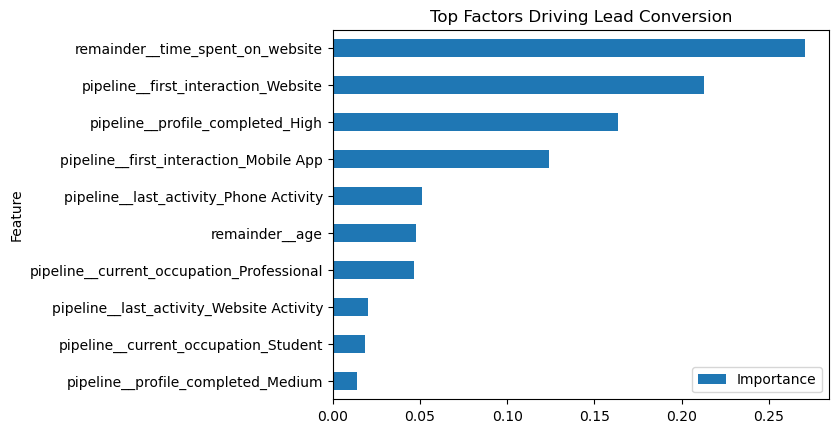

In [ ]:
feature_importance_df.head(10).plot(
    kind="barh",
    x="Feature",
    y="Importance"
)

plt.gca().invert_yaxis()
plt.title("Top Factors Driving Lead Conversion")
plt.show()

* Time spent on website is the strongest driver of conversion (importance 
0.27), followed by first interaction via website (0.21) and high profile 
completion (0.16). Gradient Boosting also surfaces first interaction via 
Mobile App as a top-5 feature (0.12) — the channel of first contact is 
informative regardless of direction, with website-first leads strongly 
favoring conversion and mobile-first leads strongly against. The model's 
top predictor is consistent with the earlier correlation analysis, and 
the ranking is more robust here as it averages across an ensemble rather 
than reflecting a single tree's splits.

## Model Serialization

In [ ]:
# Serialize the default Gradient Boosting model — the chosen final model
final_model = next(r["model"] for r in results if r["name"] == "Gradient Boosting")

os.makedirs("../models", exist_ok=True)
saved_model_path = "../app/models/learn_model.joblib"
joblib.dump(final_model, saved_model_path)

['../app/models/learn_model.joblib']

In [ ]:
saved_model = joblib.load(saved_model_path)
assert (saved_model.predict(X_test) == final_model.predict(X_test)).all(), "Model mismatch!"
print("Model verified successfully.")

Model verified successfully.


## Lead Scoring: Ranking Analysis

The model's true value as a scoring tool is captured by ranking metrics, 
not classification metrics. `predict_proba` outputs a conversion probability 
per lead — the *score*. Ranking leads by score lets sales prioritize the 
highest-probability leads regardless of any binary cutoff.

Two complementary metrics evaluate the ranking:

- **Precision@K** — of the top K ranked leads, what fraction are actual 
  converters? Measures the quality at the top of the list.
- **Cumulative gains** — if sales contacts the top X% of leads, what 
  fraction of total converters do they reach? Measures the coverage 
  achieved by working down the list.

Together they answer the question a binary classifier cannot: 
"if I can only call N leads, which N, and how many converters do I expect 
to reach?"

In [ ]:
# Score all test leads with the final model
scores = final_model.predict_proba(X_test)[:, 1]

# Build a ranked view: each lead with its score and true outcome
scored = pd.DataFrame({
    "score": scores,
    "actual": y_test.values,
}).sort_values("score", ascending=False).reset_index(drop=True)

# Precision@K for several K values
total_converters = scored["actual"].sum()
ks = [10, 25, 50, 100, 200]
precision_at_k = pd.DataFrame({
    "K": ks,
    "converters_in_top_K": [scored["actual"].head(k).sum() for k in ks],
    "precision@K": [scored["actual"].head(k).mean() for k in ks],
    "share_of_total_converters": [scored["actual"].head(k).sum() / total_converters for k in ks],
})

print(f"Total converters in test set: {total_converters} of {len(scored)} leads")
precision_at_k

Total converters in test set: 422 of 1384 leads


,K,converters_in_top_K,precision@K,share_of_total_converters
0,10,10,1.000,0.023697
1,25,25,1.000,0.059242
2,50,50,1.000,0.118483
3,100,93,0.930,0.220379
4,200,177,0.885,0.419431


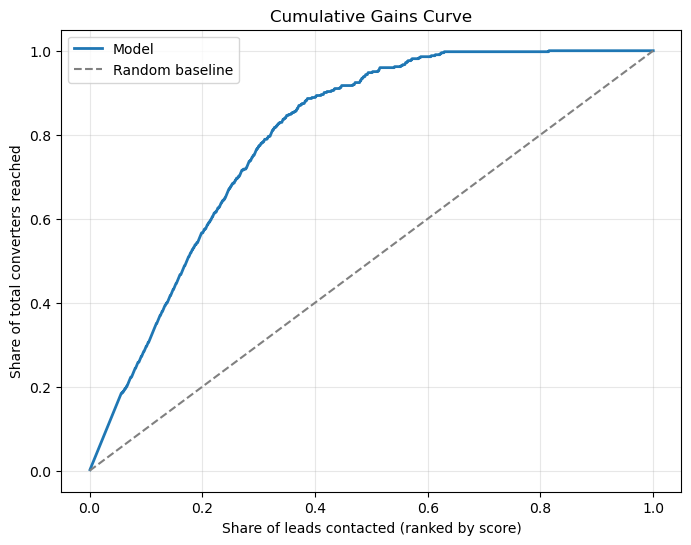

In [ ]:
# Cumulative gains curve: x = share of leads contacted, y = share of converters reached
n_leads = len(scored)
contacted_share = np.arange(1, n_leads + 1) / n_leads
converters_reached = scored["actual"].cumsum() / total_converters

plt.figure(figsize=(8, 6))
plt.plot(contacted_share, converters_reached, label="Model", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random baseline")
plt.xlabel("Share of leads contacted (ranked by score)")
plt.ylabel("Share of total converters reached")
plt.title("Cumulative Gains Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

The ranking analysis reveals the model's strongest framing. Of the test 
set's 1,384 leads (422 converters), the top 50 ranked leads are all 
converters — precision@50 = 100%. Precision remains at 93% through the 
top 100 and 88.5% through the top 200. Working down to the top 200 (14% 
of the list) reaches 42% of all converters.

Compared to random calling (which would yield ~30% conversion rate at any 
position), the model produces a ~3× lift at the top of the list. This 
quality of ranking at the top is what makes the model genuinely useful as 
a scoring tool — sales can confidently work down the ranked list and 
expect every early call to find a real converter.

## Deployment

The serialized model is saved to `models/learn_model.joblib` and loaded by the Streamlit app in `app/`. See `app/` for deployment details.

## Actionable Insights and Recommendations

* Time spent on website is the single strongest predictor of conversion. 
Sales teams should prioritize leads who engage substantially with the site, 
arrive via the website rather than the mobile app, and complete their 
profiles to a High level.
* First-interaction channel is informative in both directions: website-first 
leads convert at a much higher rate, and mobile-first leads convert 
substantially less — both groups warrant distinct outreach strategies 
rather than uniform treatment.
* Marketing variables (print, digital media, educational channels, referrals) 
contribute negligibly to the prediction. Either these channels are not 
reaching converting leads, or the dataset doesn't capture their impact — 
worth investigating before continued investment.
* The serialized model integrates into a lead scoring workflow and should 
be retrained periodically as new conversion data accumulates.